# 08. Agent Visualization (에이전트 시각화)

OpenAI Agent SDK는 **Graphviz**를 사용하여 에이전트 구조를 시각적으로 표현하는 기능을 제공합니다.

### 시각화가 보여주는 것:
- **노란색 박스**: 에이전트 (Agent)
- **녹색 타원**: 도구 (Tool)
- **회색 박스**: MCP 서버
- **실선 화살표**: 핸드오프 연결
- **점선 화살표**: 도구 연결
- **대시선 화살표**: MCP 서버 연결

### 설치:
```bash
pip install "openai-agents[viz]"
```

Graphviz도 시스템에 설치되어 있어야 합니다:
- Windows: `choco install graphviz` 또는 https://graphviz.org/download/ 에서 설치
- Mac: `brew install graphviz`
- Linux: `apt install graphviz`

### Google Colab 에서 실행

In [4]:
!apt-get install -y graphviz  # Colab에서 실행 시 주석 해제
pip install "openai-agents[viz]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.7/150.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.2/404.2 kB 14.6 MB/s eta 0:00:00


In [5]:
from dotenv import load_dotenv
load_dotenv()

True

In [6]:
import openai

Model = "gpt-5-nano"

## 1. 기본 시각화 - 단일 에이전트 + 도구

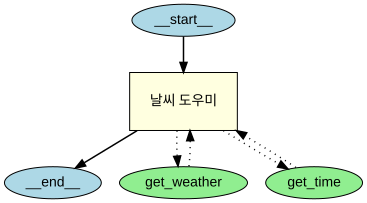

In [7]:
from agents import Agent, function_tool
from agents.extensions.visualization import draw_graph

@function_tool
def get_weather(city: str) -> str:
    """주어진 도시의 날씨 정보를 반환합니다."""
    return f"{city}의 날씨는 맑음, 기온 22도입니다."

@function_tool
def get_time(city: str) -> str:
    """주어진 도시의 현재 시간을 반환합니다."""
    return f"{city}의 현재 시간은 오후 3시입니다."

weather_agent = Agent(
    name="날씨 도우미",
    instructions="날씨와 시간 정보를 제공하는 도우미입니다.",
    model=Model,
    tools=[get_weather, get_time],
)

# 에이전트 구조를 시각화
graph = draw_graph(weather_agent)
graph

## 2. 핸드오프가 있는 다중 에이전트 시각화

여러 에이전트가 핸드오프로 연결된 구조를 시각화합니다.

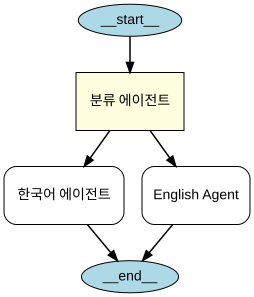

In [8]:
korean_agent = Agent(
    name="한국어 에이전트",
    instructions="한국어로만 응답합니다.",
    model=Model,
)

english_agent = Agent(
    name="English Agent",
    instructions="You only respond in English.",
    model=Model,
)

triage_agent = Agent(
    name="분류 에이전트",
    instructions="사용자의 요청 언어에 따라 적절한 에이전트에게 전달합니다.",
    model=Model,
    handoffs=[korean_agent, english_agent],
)

# 핸드오프 관계를 시각화
graph = draw_graph(triage_agent)
graph

## 3. 복잡한 에이전트 구조 시각화

도구 + 핸드오프가 결합된 실전에 가까운 구조를 시각화합니다.

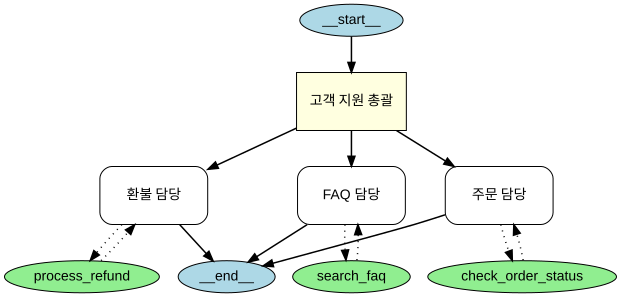

In [9]:
@function_tool
def check_order_status(order_id: str) -> str:
    """주문 상태를 조회합니다."""
    return f"주문 {order_id}: 배송 중"

@function_tool
def process_refund(order_id: str, reason: str) -> str:
    """환불을 처리합니다."""
    return f"주문 {order_id} 환불 처리 완료 (사유: {reason})"

@function_tool
def search_faq(query: str) -> str:
    """FAQ 데이터베이스에서 질문을 검색합니다."""
    return f"FAQ 검색 결과: '{query}'에 대한 답변..."

# 전문 에이전트 정의
order_agent = Agent(
    name="주문 담당",
    instructions="주문 조회 및 상태 확인을 담당합니다.",
    model=Model,
    tools=[check_order_status],
)

refund_agent = Agent(
    name="환불 담당",
    instructions="환불 요청을 처리합니다.",
    model=Model,
    tools=[process_refund],
)

faq_agent = Agent(
    name="FAQ 담당",
    instructions="자주 묻는 질문에 답변합니다.",
    model=Model,
    tools=[search_faq],
)

# 총괄 에이전트
customer_support = Agent(
    name="고객 지원 총괄",
    instructions="고객의 요청을 분류하여 적절한 전문 에이전트에게 전달합니다.",
    model=Model,
    handoffs=[order_agent, refund_agent, faq_agent],
)

# 전체 구조를 시각화
graph = draw_graph(customer_support)
graph

## 4. 시각화 저장

생성된 그래프를 파일로 저장할 수 있습니다.

In [12]:
# 파일로 저장
draw_graph(customer_support, filename="customer_support_graph")
print("customer_support_graph 파일이 생성되었습니다.")

customer_support_graph 파일이 생성되었습니다.


### 정리

| 기능 | 코드 | 설명 |
|------|------|------|
| 기본 시각화 | `draw_graph(agent)` | Jupyter에서 인라인 표시 |
| 파일 저장 | `draw_graph(agent, filename="name")` | PDF 파일로 저장 |
| 브라우저 열기 | `draw_graph(agent).view()` | 시스템 기본 뷰어로 열기 |

**시각화를 활용하면:**
- 복잡한 에이전트 관계를 한눈에 파악 가능
- 핸드오프 흐름 검증에 유용
- 문서화 및 팀 커뮤니케이션에 활용